In [1]:
import kagglehub
import os
# Download latest version
path1 = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print(os.listdir(path1)) 
BRAIN_IMAGES = os.path.join(path1, "Training")

# Download latest version
path2 = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")
print("Path to dataset files:", path2)
NEU_IMAGES = os.path.join(path2, "NEU-DET/train/images")

print(NEU_IMAGES)
print(os.listdir(NEU_IMAGES))
# Download latest version
path3 = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path3)

CHEST_IMAGES = os.path.join(path3, "chest_xray/train")
print(os.listdir(CHEST_IMAGES))
# Download latest version
path4 = kagglehub.dataset_download("apollo2506/eurosat-dataset")
print("Path to dataset files:", path4)

EUROSAT_IMAGES = os.path.join(path4, "EuroSAT")
print(os.listdir(EUROSAT_IMAGES))

['Testing', 'Training']
Path to dataset files: C:\Users\sunda\.cache\kagglehub\datasets\kaustubhdikshit\neu-surface-defect-database\versions\1
C:\Users\sunda\.cache\kagglehub\datasets\kaustubhdikshit\neu-surface-defect-database\versions\1\NEU-DET/train/images
['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Path to dataset files: C:\Users\sunda\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2
['NORMAL', 'PNEUMONIA']
Path to dataset files: C:\Users\sunda\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'label_map.json', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake', 'test.csv', 'train.csv', 'validation.csv']


In [2]:
import cv2
import numpy as np
import os
import pandas as pd
from skimage.feature import graycomatrix, graycoprops


# ======================================================
# SETTINGS
# ======================================================

OUTPUT_DIR = "glcm_5"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

IMG_SIZE = 128

EPS = 1e-10

MAX_SAMPLES = 10000

SEED = 42

np.random.seed(SEED)


# ======================================================
# DMVTD WEIGHTS
# ======================================================

A = 1 / 3
B = 1 / 3
C = 1 / 3


# ======================================================
# GLCM PARAMETERS
# ======================================================

# 5 distances
DISTANCES = [
    1,
    2,
    3,
    4,
    5
]


# 4 angles
ANGLES = [
    0,
    np.pi / 4,
    np.pi / 2,
    3 * np.pi / 4
]


# 256 gray levels
LEVELS = 256

SYMMETRIC = True

NORMED = True


# ======================================================
# 5 GLCM FEATURES
# ======================================================

GLCM_FEATURES = [
    "contrast",
    "energy",
    "homogeneity",
    "correlation",
    "entropy"
]


# ======================================================
# DATASETS
# ======================================================

DATASETS = [

    # --------------------------------------------------
    # FUL BONE
    # --------------------------------------------------

    {
        "name": "ful_bone",
        "type": "folder",
        "path": "Dataset"
    },

    {
        "name": "bone",
        "type": "folder",
        "path": "clahe_output"
    },

    {
        "name": "neu_defect",
        "type": "folder",
        "path": NEU_IMAGES
    },

    {
        "name": "brain_mri",
        "type": "folder",
        "path": BRAIN_IMAGES
    },

    {
        "name": "chest_xray",
        "type": "folder",
        "path": CHEST_IMAGES
    },

    {
        "name": "eurosat",
        "type": "folder",
        "path": EUROSAT_IMAGES
    },
]


# ======================================================
# DMVTD
# ======================================================

def compute_stats(values):

    values = np.asarray(
        values,
        dtype=np.float64
    )


    # --------------------------------------------------
    # Mean
    # --------------------------------------------------

    mean_v = np.mean(
        values
    )


    # --------------------------------------------------
    # Variance
    # --------------------------------------------------

    var_v = np.var(
        values
    )


    trans_v = (
        abs(values[0] - values[1]) +
        abs(values[1] - values[2]) +
        abs(values[2] - values[3]) +
        abs(values[3] - values[0])
    ) / 4

    weighted_fusion = (
        A * mean_v +
        B * var_v +
        C * trans_v
    )


    return (
        mean_v,
        var_v,
        trans_v,
        weighted_fusion
    )


# ======================================================
# FEATURE EXTRACTION
# ======================================================

def extract_features(img):

    # ==================================================
    # RESIZE
    # ==================================================

    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )


    # ==================================================
    # GRAYSCALE
    # ==================================================

    if len(img.shape) == 3:

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )


    # ==================================================
    # UINT8
    # ==================================================

    img = np.asarray(
        img,
        dtype=np.uint8
    )


    # ==================================================
    # CLAHE
    # ==================================================

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    img = clahe.apply(
        img
    )


    # ==================================================
    # GLCM
    # ==================================================

    glcm = graycomatrix(
        img,
        distances=DISTANCES,
        angles=ANGLES,
        levels=LEVELS,
        symmetric=SYMMETRIC,
        normed=NORMED
    )


    # ==================================================
    # STORAGE
    # ==================================================

    normal_features = []

    normal_names = []


    dmvtd_features = []

    dmvtd_names = []


    # ==================================================
    # LOOP THROUGH DISTANCES
    # ==================================================

    for distance_idx, distance in enumerate(
        DISTANCES
    ):


        # ==================================================
        # STANDARD GLCM FEATURES
        # ==================================================

        contrast = graycoprops(
            glcm,
            "contrast"
        )[
            distance_idx,
            :
        ]


        energy = graycoprops(
            glcm,
            "energy"
        )[
            distance_idx,
            :
        ]


        homogeneity = graycoprops(
            glcm,
            "homogeneity"
        )[
            distance_idx,
            :
        ]


        correlation = graycoprops(
            glcm,
            "correlation"
        )[
            distance_idx,
            :
        ]


        # ==================================================
        # ENTROPY
        # ==================================================

        entropy = []


        for angle_idx in range(
            len(ANGLES)
        ):

            P = glcm[
                :,
                :,
                distance_idx,
                angle_idx
            ]


            entropy_value = -np.sum(
                P * np.log2(
                    P + EPS
                )
            )


            entropy.append(
                entropy_value
            )


        entropy = np.asarray(
            entropy,
            dtype=np.float64
        )


        # ==================================================
        # STORE ALL 5 FEATURES
        # ==================================================

        feature_data = {

            "contrast": contrast,

            "energy": energy,

            "homogeneity": homogeneity,

            "correlation": correlation,

            "entropy": entropy

        }


        # ==================================================
        # NORMAL GLCM
        #
        # 1 distance
        # ×
        # 4 angles
        # ×
        # 5 features
        #
        # = 20 features per distance
        # ==================================================

        for angle_idx, angle in enumerate(
            ANGLES
        ):

            angle_degree = int(
                round(
                    np.degrees(angle)
                )
            )


            # ------------------------------------------
            # CONTRAST
            # ------------------------------------------

            normal_features.append(
                contrast[
                    angle_idx
                ]
            )

            normal_names.append(
                f"d{distance}_a{angle_degree}_contrast"
            )


            # ------------------------------------------
            # ENERGY
            # ------------------------------------------

            normal_features.append(
                energy[
                    angle_idx
                ]
            )

            normal_names.append(
                f"d{distance}_a{angle_degree}_energy"
            )


            # ------------------------------------------
            # HOMOGENEITY
            # ------------------------------------------

            normal_features.append(
                homogeneity[
                    angle_idx
                ]
            )

            normal_names.append(
                f"d{distance}_a{angle_degree}_homogeneity"
            )


            # ------------------------------------------
            # CORRELATION
            # ------------------------------------------

            normal_features.append(
                correlation[
                    angle_idx
                ]
            )

            normal_names.append(
                f"d{distance}_a{angle_degree}_correlation"
            )


            # ------------------------------------------
            # ENTROPY
            # ------------------------------------------

            normal_features.append(
                entropy[
                    angle_idx
                ]
            )

            normal_names.append(
                f"d{distance}_a{angle_degree}_entropy"
            )


        # ==================================================
        # DMVTD
        #
        # For EACH distance:
        #
        # 5 features
        # ×
        # 4 statistics
        #
        # = 20 DMVTD features per distance
        # ==================================================

        for feature_name, values in feature_data.items():

            (
                mean_v,
                var_v,
                trans_v,
                weighted_v
            ) = compute_stats(
                values
            )


            # ------------------------------------------
            # MEAN
            # ------------------------------------------

            dmvtd_features.append(
                mean_v
            )

            dmvtd_names.append(
                f"d{distance}_{feature_name}_mean"
            )


            # ------------------------------------------
            # VARIANCE
            # ------------------------------------------

            dmvtd_features.append(
                var_v
            )

            dmvtd_names.append(
                f"d{distance}_{feature_name}_variance"
            )


            # ------------------------------------------
            # TRANSITION
            # ------------------------------------------

            dmvtd_features.append(
                trans_v
            )

            dmvtd_names.append(
                f"d{distance}_{feature_name}_transition"
            )


            # ------------------------------------------
            # WEIGHTED FUSION
            # ------------------------------------------

            dmvtd_features.append(
                weighted_v
            )

            dmvtd_names.append(
                f"d{distance}_{feature_name}_weighted_fusion"
            )


    # ==================================================
    # HYBRID
    #
    # NORMAL = 100
    #
    # DMVTD = 100
    #
    # HYBRID = 200
    # ==================================================

    hybrid_features = (
        normal_features +
        dmvtd_features
    )


    hybrid_names = (
        normal_names +
        dmvtd_names
    )


    # ==================================================
    # SAFETY CHECK
    # ==================================================

    assert len(normal_features) == 100, (
        f"Normal feature count is "
        f"{len(normal_features)}, expected 100"
    )


    assert len(dmvtd_features) == 100, (
        f"DMVTD feature count is "
        f"{len(dmvtd_features)}, expected 100"
    )


    assert len(hybrid_features) == 200, (
        f"Hybrid feature count is "
        f"{len(hybrid_features)}, expected 200"
    )


    return (

        np.asarray(
            normal_features,
            dtype=np.float64
        ),

        np.asarray(
            dmvtd_features,
            dtype=np.float64
        ),

        np.asarray(
            hybrid_features,
            dtype=np.float64
        ),

        normal_names,

        dmvtd_names,

        hybrid_names
    )


# ======================================================
# PROCESS DATASET
# ======================================================

def process_dataset(
    images,
    labels,
    dataset_name
):

    normal_list = []

    dmvtd_list = []

    hybrid_list = []

    valid_labels = []


    normal_names = None

    dmvtd_names = None

    hybrid_names = None


    total = len(
        images
    )


    print(
        "\n" + "=" * 60
    )

    print(
        f"Extracting features: {dataset_name}"
    )

    print(
        f"Total images: {total}"
    )

    print(
        "=" * 60
    )


    # ==================================================
    # IMAGE LOOP
    # ==================================================

    for i, (img, lbl) in enumerate(
        zip(images, labels)
    ):

        try:

            # ------------------------------------------
            # Convert image
            # ------------------------------------------

            img = np.asarray(
                img,
                dtype=np.uint8
            )


            # ------------------------------------------
            # Extract features
            # ------------------------------------------

            (
                normal,
                dmvtd,
                hybrid,
                n_names,
                d_names,
                h_names
            ) = extract_features(
                img
            )


            # ------------------------------------------
            # Store names
            # ------------------------------------------

            if normal_names is None:

                normal_names = n_names

                dmvtd_names = d_names

                hybrid_names = h_names


            # ------------------------------------------
            # Store features
            # ------------------------------------------

            normal_list.append(
                normal
            )

            dmvtd_list.append(
                dmvtd
            )

            hybrid_list.append(
                hybrid
            )


            # ------------------------------------------
            # Store label
            # ------------------------------------------

            valid_labels.append(
                lbl
            )


        except Exception as e:

            print(
                f"ERROR image {i}: {e}"
            )

            continue


        # ------------------------------------------
        # Progress
        # ------------------------------------------

        if (i + 1) % 100 == 0:

            print(
                f"{i + 1}/{total} images processed"
            )


    # ==================================================
    # SAVE CSV FILES
    # ==================================================

    save_csv(
        normal_list,
        dmvtd_list,
        hybrid_list,
        valid_labels,
        dataset_name,
        normal_names,
        dmvtd_names,
        hybrid_names
    )


# ======================================================
# SAVE 3 CSV FILES
# ======================================================

def save_csv(
    normal_list,
    dmvtd_list,
    hybrid_list,
    labels,
    dataset_name,
    normal_names,
    dmvtd_names,
    hybrid_names
):

    # ==================================================
    # OUTPUT DIRECTORY
    # ==================================================

    dataset_dir = os.path.join(
        OUTPUT_DIR,
        dataset_name
    )


    os.makedirs(
        dataset_dir,
        exist_ok=True
    )


    # ==================================================
    # NORMAL CSV
    # ==================================================

    normal_df = pd.DataFrame(
        normal_list,
        columns=normal_names
    )


    normal_df["label"] = labels


    normal_path = os.path.join(
        dataset_dir,
        "normal.csv"
    )


    normal_df.to_csv(
        normal_path,
        index=False
    )


    # ==================================================
    # DMVTD CSV
    # ==================================================

    dmvtd_df = pd.DataFrame(
        dmvtd_list,
        columns=dmvtd_names
    )


    dmvtd_df["label"] = labels


    dmvtd_path = os.path.join(
        dataset_dir,
        "dmvtd.csv"
    )


    dmvtd_df.to_csv(
        dmvtd_path,
        index=False
    )


    # ==================================================
    # HYBRID CSV
    # ==================================================

    hybrid_df = pd.DataFrame(
        hybrid_list,
        columns=hybrid_names
    )


    hybrid_df["label"] = labels


    hybrid_path = os.path.join(
        dataset_dir,
        "hybrid.csv"
    )


    hybrid_df.to_csv(
        hybrid_path,
        index=False
    )


    # ==================================================
    # PRINT RESULTS
    # ==================================================

    print(
        "\n" + "=" * 60
    )

    print(
        f"CSV FILES SAVED FOR: {dataset_name}"
    )

    print(
        "=" * 60
    )


    print(
        f"\nNormal:"
    )

    print(
        f"  {normal_path}"
    )

    print(
        f"  Shape = {normal_df.shape}"
    )


    print(
        f"\nDMVTD:"
    )

    print(
        f"  {dmvtd_path}"
    )

    print(
        f"  Shape = {dmvtd_df.shape}"
    )


    print(
        f"\nHybrid:"
    )

    print(
        f"  {hybrid_path}"
    )

    print(
        f"  Shape = {hybrid_df.shape}"
    )


    # ==================================================
    # FEATURE COUNT
    # ==================================================

    print(
        "\nFeature counts:"
    )

    print(
        f"Normal = {len(normal_names)}"
    )

    print(
        f"DMVTD  = {len(dmvtd_names)}"
    )

    print(
        f"Hybrid = {len(hybrid_names)}"
    )


# ======================================================
# FOLDER DATASET
# ======================================================

def process_folder_dataset(
    dataset
):

    path = dataset["path"]

    name = dataset["name"]


    print(
        "\n" + "=" * 60
    )

    print(
        f"Processing dataset: {name}"
    )

    print(
        f"Path: {path}"
    )

    print(
        "=" * 60
    )


    # ==================================================
    # CHECK DATASET
    # ==================================================

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"Dataset not found: {path}"
        )


    # ==================================================
    # FIND CLASS DIRECTORIES
    # ==================================================

    class_dirs = [

        d

        for d in sorted(
            os.listdir(path)
        )

        if os.path.isdir(
            os.path.join(
                path,
                d
            )
        )
    ]


    if len(class_dirs) == 0:

        raise ValueError(
            f"No class folders found in {path}"
        )


    n_classes = len(
        class_dirs
    )


    # ==================================================
    # BALANCED SAMPLE COUNT
    # ==================================================

    samples_per_class = (
        MAX_SAMPLES //
        n_classes
    )


    print(
        f"\nNumber of classes: {n_classes}"
    )

    print(
        f"Maximum samples: {MAX_SAMPLES}"
    )

    print(
        f"Samples per class: "
        f"{samples_per_class}"
    )


    # ==================================================
    # STORE PATH + LABEL
    # ==================================================

    image_data = []


    # ==================================================
    # READ EACH CLASS
    # ==================================================

    for class_name in class_dirs:

        class_path = os.path.join(
            path,
            class_name
        )


        class_files = []


        # ----------------------------------------------
        # Find images
        # ----------------------------------------------

        for img_name in os.listdir(
            class_path
        ):

            if not img_name.lower().endswith(
                (
                    ".jpg",
                    ".jpeg",
                    ".png",
                    ".bmp",
                    ".tif",
                    ".tiff"
                )
            ):

                continue


            img_path = os.path.join(
                class_path,
                img_name
            )


            class_files.append(
                img_path
            )


        # ----------------------------------------------
        # Shuffle
        # ----------------------------------------------

        np.random.shuffle(
            class_files
        )


        # ----------------------------------------------
        # Select balanced samples
        # ----------------------------------------------

        selected = class_files[
            :samples_per_class
        ]


        print(
            f"{class_name}: "
            f"{len(selected)} images"
        )


        # ----------------------------------------------
        # Store path + label
        # ----------------------------------------------

        for img_path in selected:

            image_data.append(
                (
                    img_path,
                    class_name
                )
            )


    # ==================================================
    # FINAL SHUFFLE
    # ==================================================

    np.random.shuffle(
        image_data
    )


    # ==================================================
    # LOAD IMAGES
    # ==================================================

    images = []

    labels = []


    for img_path, label in image_data:

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )


        # ----------------------------------------------
        # Only keep successfully loaded images
        # ----------------------------------------------

        if img is not None:

            images.append(
                img
            )

            labels.append(
                label
            )

        else:

            print(
                f"WARNING: Could not read "
                f"{img_path}"
            )


    # ==================================================
    # PRINT LOADED COUNT
    # ==================================================

    print(
        f"\nSuccessfully loaded: "
        f"{len(images)} images"
    )


    # ==================================================
    # EXTRACT FEATURES
    # ==================================================

    process_dataset(
        images,
        labels,
        name
    )


# ======================================================
# RUN ALL DATASETS
# ======================================================

def run_all_datasets():

    print(
        "\n" + "=" * 70
    )

    print(
        "GLCM + DMVTD + HYBRID FEATURE EXTRACTION"
    )

    print(
        "=" * 70
    )


    # ==================================================
    # PROCESS EACH DATASET
    # ==================================================

    for dataset in DATASETS:

        dtype = dataset["type"]


        if dtype == "folder":

            process_folder_dataset(
                dataset
            )


        else:

            print(
                f"\nSkipping "
                f"{dataset['name']}"
            )


    # ==================================================
    # FINAL SUMMARY
    # ==================================================

    print(
        "\n" + "=" * 70
    )

    print(
        "ALL DATASETS COMPLETE"
    )

    print(
        "=" * 70
    )


    print(
        "\nGenerated files:"
    )


    for dataset in DATASETS:

        name = dataset["name"]


        print(
            f"\n{name}/"
        )


        print(
            f"  {OUTPUT_DIR}/"
            f"{name}/normal.csv"
        )


        print(
            f"  {OUTPUT_DIR}/"
            f"{name}/dmvtd.csv"
        )


        print(
            f"  {OUTPUT_DIR}/"
            f"{name}/hybrid.csv"
        )


    print(
        "\n" + "=" * 70
    )


# ======================================================
# MAIN
# ======================================================

if __name__ == "__main__":

    run_all_datasets()


GLCM + DMVTD + HYBRID FEATURE EXTRACTION

Processing dataset: neu_defect
Path: C:\Users\sunda\.cache\kagglehub\datasets\kaustubhdikshit\neu-surface-defect-database\versions\1\NEU-DET/train/images

Number of classes: 6
Maximum samples: 10000
Samples per class: 1666
crazing: 240 images
inclusion: 240 images
patches: 240 images
pitted_surface: 240 images
rolled-in_scale: 240 images
scratches: 240 images

Successfully loaded: 1440 images

Extracting features: neu_defect
Total images: 1440
100/1440 images processed
200/1440 images processed
300/1440 images processed
400/1440 images processed
500/1440 images processed
600/1440 images processed
700/1440 images processed
800/1440 images processed
900/1440 images processed
1000/1440 images processed
1100/1440 images processed
1200/1440 images processed
1300/1440 images processed
1400/1440 images processed

CSV FILES SAVED FOR: neu_defect

Normal:
  glcm_5\neu_defect\normal.csv
  Shape = (1440, 101)

DMVTD:
  glcm_5\neu_defect\dmvtd.csv
  Shape

In [ ]:
from google.colab import files
import shutil

shutil.make_archive('/content/glcm_5', 'zip', '/content/glcm_5')
files.download('/content/glcm_5.zip')


Detected Datasets:
bone
brain_mri
chest_xray
eurosat
ful_bone
neu_defect

################################################################################
RUNNING: BONE
################################################################################

bone_RAW

----- Fold 1/5 -----
  SVM: acc=0.8119 prec=0.8268 rec=0.8119 f1=0.8116
  KNN: acc=0.7806 prec=0.7827 rec=0.7806 f1=0.7809
  RF: acc=0.7759 prec=0.7789 rec=0.7759 f1=0.7762
  LR: acc=0.8135 prec=0.8200 rec=0.8135 f1=0.8137
  DT: acc=0.7367 prec=0.7411 rec=0.7367 f1=0.7371
  ET: acc=0.7821 prec=0.7856 rec=0.7821 f1=0.7825
  ANN: acc=0.8229 prec=0.8300 rec=0.8229 f1=0.8230

----- Fold 2/5 -----
  SVM: acc=0.8056 prec=0.8179 rec=0.8056 f1=0.8055
  KNN: acc=0.8009 prec=0.8029 rec=0.8009 f1=0.8012
  RF: acc=0.7962 prec=0.7978 rec=0.7962 f1=0.7965
  LR: acc=0.8103 prec=0.8168 rec=0.8103 f1=0.8105
  DT: acc=0.7367 prec=0.7446 rec=0.7367 f1=0.7368
  ET: acc=0.8009 prec=0.8029 rec=0.8009 f1=0.8012
  ANN: acc=0.8260 prec=0.8280 rec=0.8260

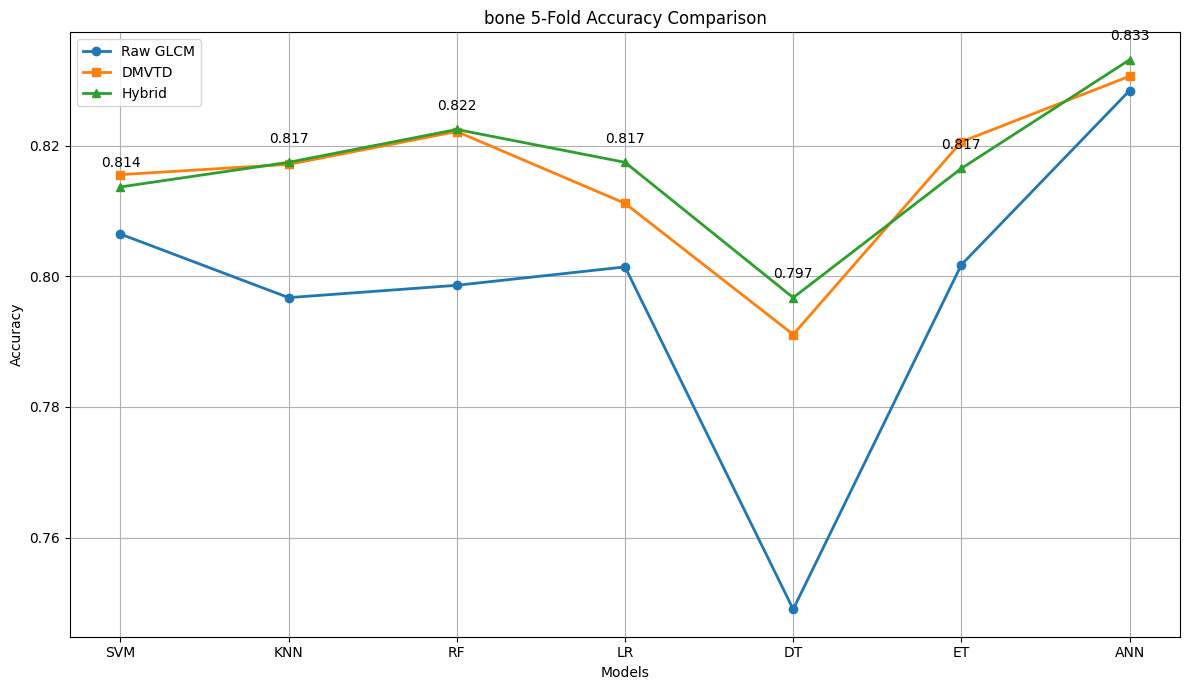


################################################################################
RUNNING: BRAIN_MRI
################################################################################

brain_mri_RAW

----- Fold 1/5 -----
  SVM: acc=0.8107 prec=0.8179 rec=0.8107 f1=0.8093
  KNN: acc=0.8464 prec=0.8467 rec=0.8464 f1=0.8461
  RF: acc=0.8812 prec=0.8818 rec=0.8812 f1=0.8807
  LR: acc=0.8295 prec=0.8308 rec=0.8295 f1=0.8291
  DT: acc=0.7143 prec=0.7484 rec=0.7143 f1=0.7173
  ET: acc=0.8938 prec=0.8937 rec=0.8938 f1=0.8933
  ANN: acc=0.8902 prec=0.8907 rec=0.8902 f1=0.8891

----- Fold 2/5 -----
  SVM: acc=0.8330 prec=0.8393 rec=0.8330 f1=0.8321
  KNN: acc=0.8670 prec=0.8689 rec=0.8670 f1=0.8663
  RF: acc=0.8946 prec=0.8954 rec=0.8946 f1=0.8939
  LR: acc=0.8438 prec=0.8454 rec=0.8438 f1=0.8439
  DT: acc=0.7071 prec=0.7283 rec=0.7071 f1=0.7125
  ET: acc=0.9036 prec=0.9042 rec=0.9036 f1=0.9026
  ANN: acc=0.9000 prec=0.9007 rec=0.9000 f1=0.8991

----- Fold 3/5 -----
  SVM: acc=0.8223 prec=0.8331 r

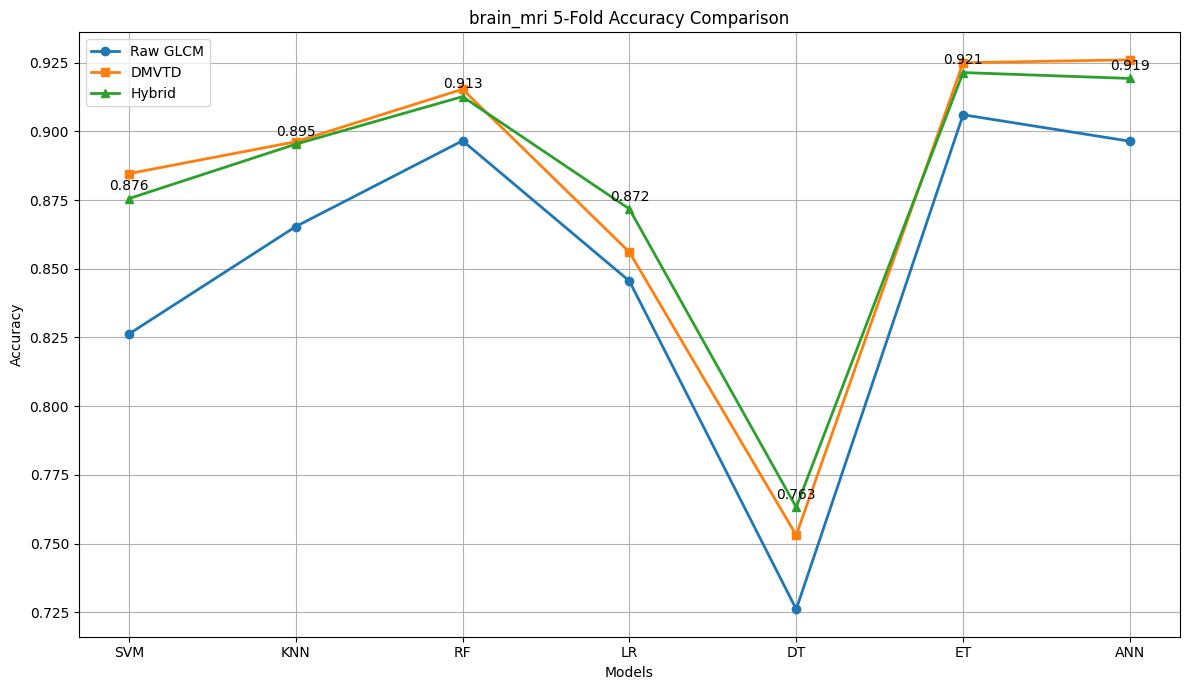


################################################################################
RUNNING: CHEST_XRAY
################################################################################

chest_xray_RAW

----- Fold 1/5 -----
  SVM: acc=0.9224 prec=0.9239 rec=0.9224 f1=0.9230
  KNN: acc=0.8918 prec=0.9006 rec=0.8918 f1=0.8943
  RF: acc=0.9138 prec=0.9145 rec=0.9138 f1=0.9141
  LR: acc=0.9349 prec=0.9346 rec=0.9349 f1=0.9347
  DT: acc=0.8831 prec=0.8882 rec=0.8831 f1=0.8850
  ET: acc=0.9148 prec=0.9177 rec=0.9148 f1=0.9158
  ANN: acc=0.9416 prec=0.9411 rec=0.9416 f1=0.9412

----- Fold 2/5 -----
  SVM: acc=0.9051 prec=0.9075 rec=0.9051 f1=0.9060
  KNN: acc=0.8878 prec=0.8958 rec=0.8878 f1=0.8903
  RF: acc=0.9032 prec=0.9033 rec=0.9032 f1=0.9032
  LR: acc=0.9214 prec=0.9210 rec=0.9214 f1=0.9212
  DT: acc=0.8667 prec=0.8695 rec=0.8667 f1=0.8679
  ET: acc=0.9041 prec=0.9078 rec=0.9041 f1=0.9054
  ANN: acc=0.9291 prec=0.9287 rec=0.9291 f1=0.9289

----- Fold 3/5 -----
  SVM: acc=0.9175 prec=0.9190

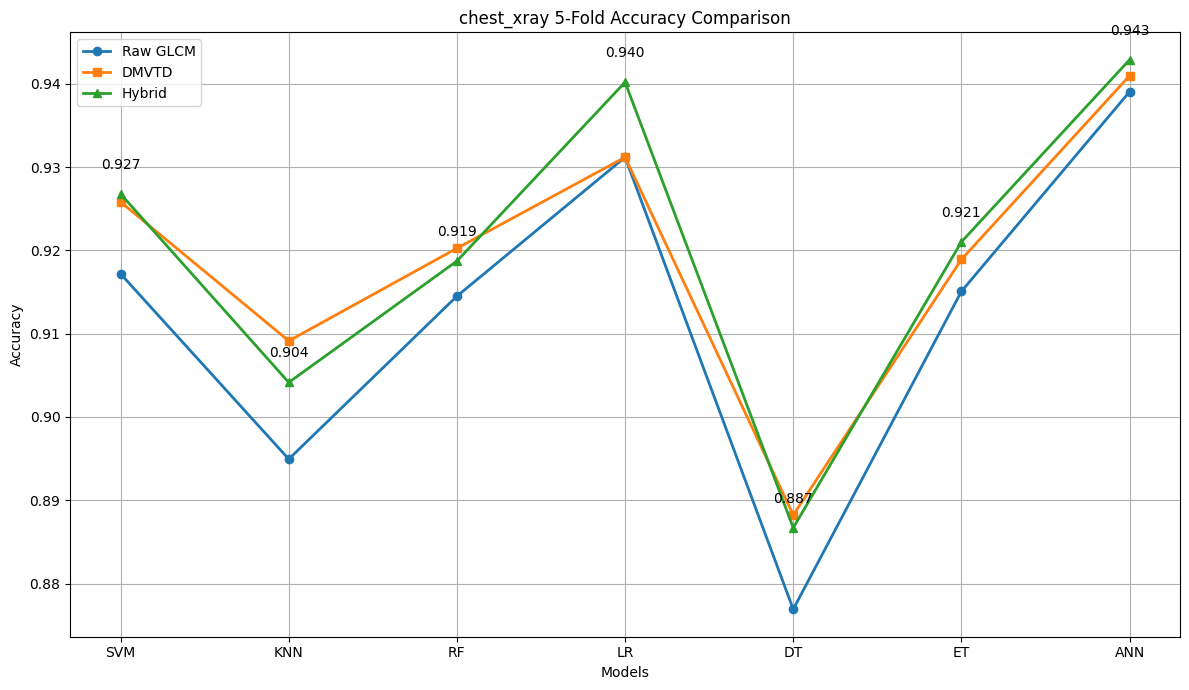


################################################################################
RUNNING: EUROSAT
################################################################################

eurosat_RAW

----- Fold 1/5 -----
  SVM: acc=0.7360 prec=0.7346 rec=0.7360 f1=0.7265
  KNN: acc=0.7070 prec=0.7032 rec=0.7070 f1=0.7002
  RF: acc=0.7645 prec=0.7621 rec=0.7645 f1=0.7615
  LR: acc=0.7420 prec=0.7378 rec=0.7420 f1=0.7349
  DT: acc=0.5720 prec=0.4720 rec=0.5720 f1=0.4995
  ET: acc=0.7725 prec=0.7708 rec=0.7725 f1=0.7691
  ANN: acc=0.7995 prec=0.7975 rec=0.7995 f1=0.7959

----- Fold 2/5 -----
  SVM: acc=0.7245 prec=0.7197 rec=0.7245 f1=0.7158
  KNN: acc=0.7195 prec=0.7152 rec=0.7195 f1=0.7142
  RF: acc=0.7560 prec=0.7517 rec=0.7560 f1=0.7524
  LR: acc=0.7430 prec=0.7385 rec=0.7430 f1=0.7382
  DT: acc=0.5735 prec=0.5672 rec=0.5735 f1=0.5128
  ET: acc=0.7560 prec=0.7514 rec=0.7560 f1=0.7514
  ANN: acc=0.7995 prec=0.7943 rec=0.7995 f1=0.7942

----- Fold 3/5 -----
  SVM: acc=0.7465 prec=0.7434 rec=0

C:\Users\sunda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sunda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sunda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

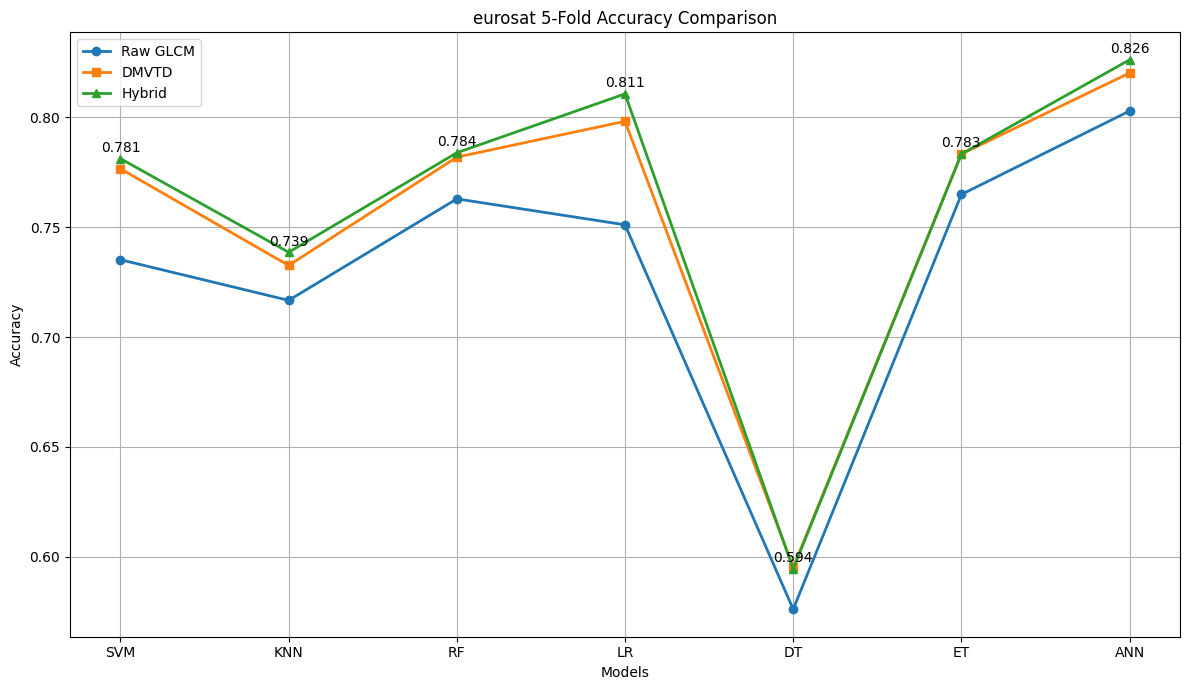


################################################################################
RUNNING: FUL_BONE
################################################################################

ful_bone_RAW

----- Fold 1/5 -----
  SVM: acc=0.8133 prec=0.8646 rec=0.8133 f1=0.8071
  KNN: acc=0.8133 prec=0.8379 rec=0.8133 f1=0.8103
  RF: acc=0.8000 prec=0.8113 rec=0.8000 f1=0.7985
  LR: acc=0.7867 prec=0.8009 rec=0.7867 f1=0.7845
  DT: acc=0.7467 prec=0.7516 rec=0.7467 f1=0.7458
  ET: acc=0.8267 prec=0.8329 rec=0.8267 f1=0.8260
  ANN: acc=0.8667 prec=0.8766 rec=0.8667 f1=0.8660

----- Fold 2/5 -----
  SVM: acc=0.6533 prec=0.7120 rec=0.6533 f1=0.6252
  KNN: acc=0.6667 prec=0.6879 rec=0.6667 f1=0.6555
  RF: acc=0.6400 prec=0.6441 rec=0.6400 f1=0.6364
  LR: acc=0.6667 prec=0.7222 rec=0.6667 f1=0.6424
  DT: acc=0.6267 prec=0.6395 rec=0.6267 f1=0.6160
  ET: acc=0.6800 prec=0.6840 rec=0.6800 f1=0.6776
  ANN: acc=0.6533 prec=0.6971 rec=0.6533 f1=0.6308

----- Fold 3/5 -----
  SVM: acc=0.7432 prec=0.7775 rec

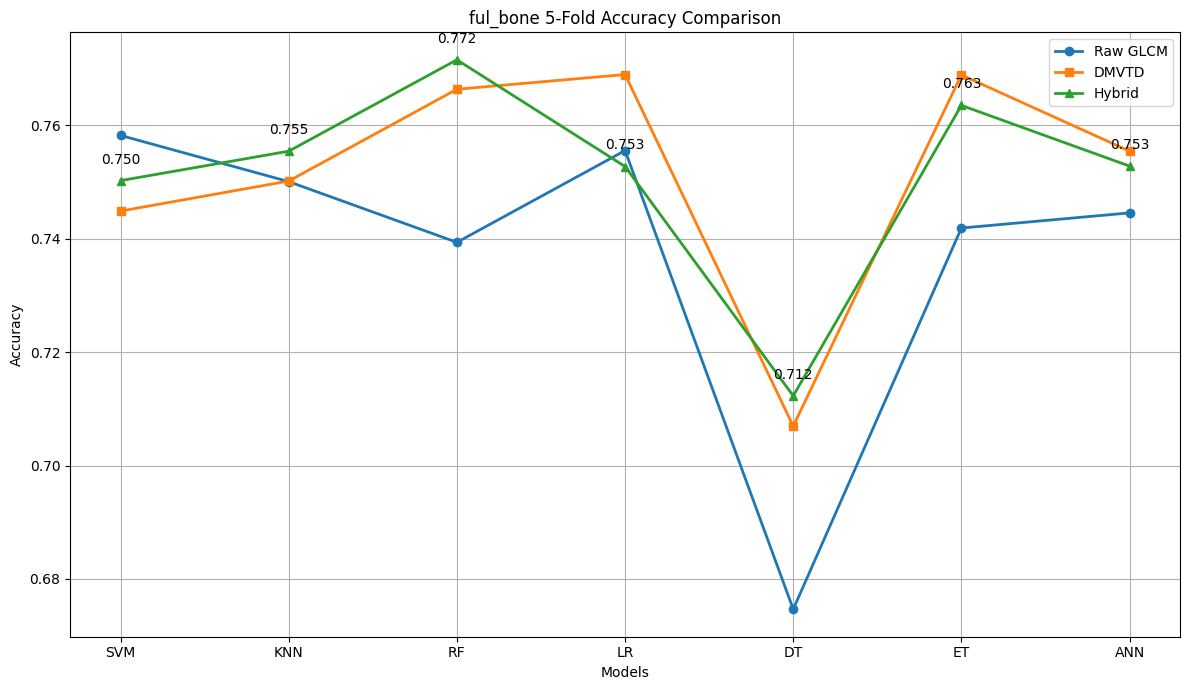


################################################################################
RUNNING: NEU_DEFECT
################################################################################

neu_defect_RAW

----- Fold 1/5 -----
  SVM: acc=0.9410 prec=0.9440 rec=0.9410 f1=0.9413
  KNN: acc=0.9375 prec=0.9426 rec=0.9375 f1=0.9373
  RF: acc=0.9583 prec=0.9606 rec=0.9583 f1=0.9585
  LR: acc=0.9757 prec=0.9760 rec=0.9757 f1=0.9757
  DT: acc=0.9132 prec=0.9164 rec=0.9132 f1=0.9125
  ET: acc=0.9792 prec=0.9800 rec=0.9792 f1=0.9792
  ANN: acc=0.9757 prec=0.9758 rec=0.9757 f1=0.9757

----- Fold 2/5 -----
  SVM: acc=0.9444 prec=0.9489 rec=0.9444 f1=0.9444
  KNN: acc=0.9479 prec=0.9546 rec=0.9479 f1=0.9474
  RF: acc=0.9722 prec=0.9730 rec=0.9722 f1=0.9722
  LR: acc=0.9896 prec=0.9896 rec=0.9896 f1=0.9895
  DT: acc=0.9028 prec=0.9035 rec=0.9028 f1=0.9030
  ET: acc=0.9722 prec=0.9726 rec=0.9722 f1=0.9722
  ANN: acc=0.9826 prec=0.9827 rec=0.9826 f1=0.9826

----- Fold 3/5 -----
  SVM: acc=0.9097 prec=0.9131

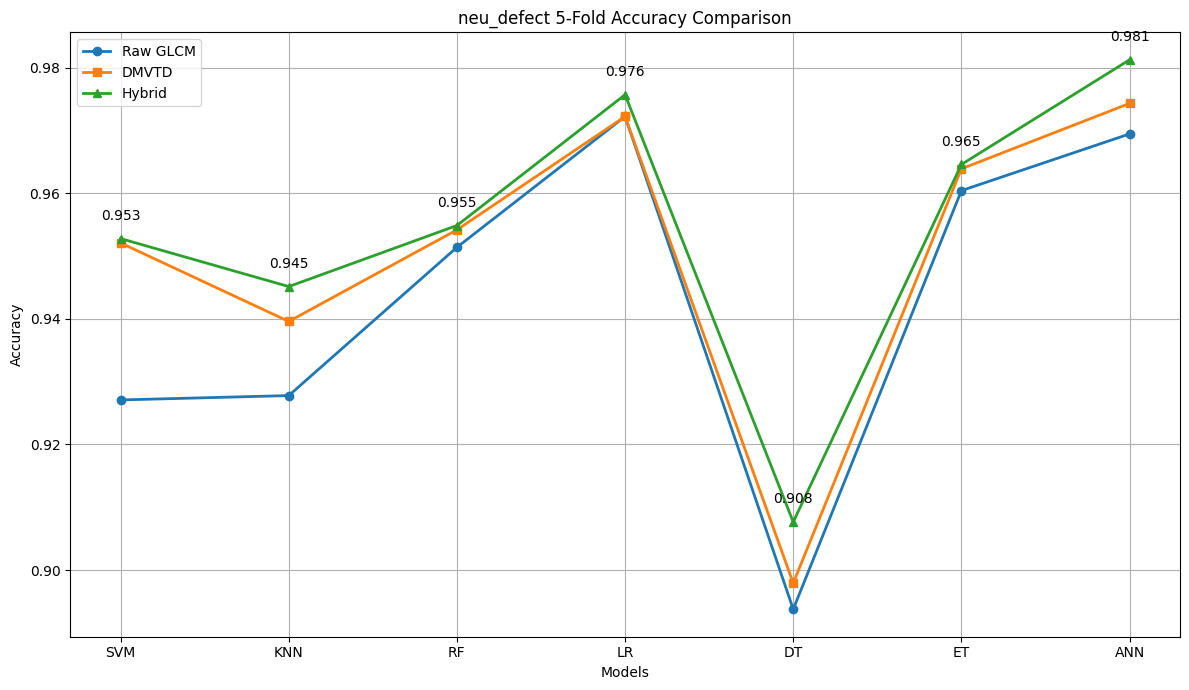

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


# =====================================================
# SETTINGS
# =====================================================
GLCM_DIR = "glcm_5"
N_SPLITS = 5
RANDOM_STATE = 42
EPOCHS = 100
BATCH_SIZE = 32

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


# =====================================================
# ANN MODEL
# =====================================================
class ANN(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# =====================================================
# TRAIN ANN (one fold)
# =====================================================
def train_ann(X_train, X_test, y_train, verbose=False):
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    input_size = X_train.shape[1]
    num_classes = len(np.unique(y_train))

    model = ANN(input_size, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if verbose and (epoch + 1) % 100 == 0:
            print(f"    Epoch [{epoch + 1}/{EPOCHS}] Loss={total_loss:.4f}")

    model.eval()

    with torch.no_grad():
        X_test_tensor = X_test_tensor.to(device)
        outputs = model(X_test_tensor)
        _, predicted = torch.max(outputs, 1)
        y_pred = predicted.cpu().numpy()

    return y_pred


# =====================================================
# SHOW CONFUSION MATRIX
# =====================================================
def plot_confusion_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(title)
    plt.tight_layout()
    plt.show()


# =====================================================
# LOAD RAW FEATURES / LABELS (no scaling/imputing here)
# =====================================================
def load_features_labels(file_path):
    df = pd.read_csv(file_path)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df["label"])

    X = df.drop(columns=["label"])
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan)

    return X.to_numpy(), y


# =====================================================
# RUN ONE CSV WITH 5-FOLD STRATIFIED CV
# =====================================================
def run_experiment(file_path, dataset_name):
    print("\n" + "=" * 70)
    print(dataset_name)
    print("=" * 70)

    X_raw, y = load_features_labels(file_path)

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    model_builders = {
        "SVM": lambda: SVC(kernel="rbf", C=1, gamma="scale"),
        "KNN": lambda: KNeighborsClassifier(n_neighbors=5),
        "RF": lambda: RandomForestClassifier(
            n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "LR": lambda: LogisticRegression(
            max_iter=500, random_state=RANDOM_STATE
        ),
        "DT": lambda: DecisionTreeClassifier(
            max_depth=5, random_state=RANDOM_STATE
        ),
        "ET": lambda: ExtraTreesClassifier(
            n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
        ),
    }

    model_names = list(model_builders.keys()) + ["ANN"]

    # Per-model fold-wise metrics
    fold_accuracies = {name: [] for name in model_names}
    fold_precisions = {name: [] for name in model_names}
    fold_recalls = {name: [] for name in model_names}
    fold_f1s = {name: [] for name in model_names}

    # Out-of-fold predictions (for McNemar's test), aligned to y
    oof_preds = {name: np.zeros_like(y) for name in model_names}

    fold_num = 0
    for train_idx, test_idx in skf.split(X_raw, y):
        fold_num += 1
        print(f"\n----- Fold {fold_num}/{N_SPLITS} -----")

        X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Fit imputer + scaler on TRAIN fold only, apply to both
        imputer = SimpleImputer(strategy="mean")
        X_train = imputer.fit_transform(X_train_raw)
        X_test = imputer.transform(X_test_raw)

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # ---------------- sklearn models ----------------
        for name, build_model in model_builders.items():
            model = build_model()
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            precision = precision_score(
                y_test, y_pred, average="weighted", zero_division=0
            )
            recall = recall_score(
                y_test, y_pred, average="weighted", zero_division=0
            )
            f1 = f1_score(
                y_test, y_pred, average="weighted", zero_division=0
            )

            print(f"  {name}: acc={acc:.4f} prec={precision:.4f} "
                  f"rec={recall:.4f} f1={f1:.4f}")

            fold_accuracies[name].append(acc)
            fold_precisions[name].append(precision)
            fold_recalls[name].append(recall)
            fold_f1s[name].append(f1)

            oof_preds[name][test_idx] = y_pred

        # ---------------- ANN ----------------
        y_pred_ann = train_ann(X_train, X_test, y_train)

        acc = accuracy_score(y_test, y_pred_ann)
        precision = precision_score(
            y_test, y_pred_ann, average="weighted", zero_division=0
        )
        recall = recall_score(
            y_test, y_pred_ann, average="weighted", zero_division=0
        )
        f1 = f1_score(
            y_test, y_pred_ann, average="weighted", zero_division=0
        )

        print(f"  ANN: acc={acc:.4f} prec={precision:.4f} "
              f"rec={recall:.4f} f1={f1:.4f}")

        fold_accuracies["ANN"].append(acc)
        fold_precisions["ANN"].append(precision)
        fold_recalls["ANN"].append(recall)
        fold_f1s["ANN"].append(f1)

        oof_preds["ANN"][test_idx] = y_pred_ann

    # ---------------- Summary across folds ----------------
    print(f"\n--- {dataset_name}: 5-fold CV summary (mean ± std) ---")
    mean_accuracies = []
    for name in model_names:
        accs = np.array(fold_accuracies[name])
        precs = np.array(fold_precisions[name])
        recs = np.array(fold_recalls[name])
        f1s = np.array(fold_f1s[name])

        print(
            f"{name}: "
            f"acc={accs.mean():.4f}±{accs.std():.4f}  "
            f"prec={precs.mean():.4f}±{precs.std():.4f}  "
            f"rec={recs.mean():.4f}±{recs.std():.4f}  "
            f"f1={f1s.mean():.4f}±{f1s.std():.4f}"
        )

        mean_accuracies.append(accs.mean())

        # Final confusion matrix / report on pooled out-of-fold predictions
        print(f"\nOut-of-fold classification report — {name}:")
        print(classification_report(y, oof_preds[name]))

    return {
        "model_names": model_names,
        "mean_accuracies": mean_accuracies,
        "fold_accuracies": fold_accuracies,   # dict: model -> list of 10 acc values
        "oof_preds": oof_preds,               # dict: model -> full-length pred array
        "y_true": y,
    }


# =====================================================
# WILCOXON SIGNED-RANK TEST (per model, across folds)
# =====================================================
def run_wilcoxon_tests(dataset_name, model_names,
                        raw_fold_acc, dmvtd_fold_acc, hybrid_fold_acc):
    print(f"\n--- {dataset_name}: Wilcoxon signed-rank tests "
          f"(fold accuracies, Raw vs DMVTD / Raw vs Hybrid) ---")

    for name in model_names:
        raw_vals = np.array(raw_fold_acc[name])
        dmvtd_vals = np.array(dmvtd_fold_acc[name])
        hybrid_vals = np.array(hybrid_fold_acc[name])

        # Wilcoxon requires at least one non-zero difference
        try:
            if np.allclose(raw_vals, dmvtd_vals):
                p_raw_dmvtd = float("nan")
            else:
                _, p_raw_dmvtd = wilcoxon(raw_vals, dmvtd_vals)
        except ValueError:
            p_raw_dmvtd = float("nan")

        try:
            if np.allclose(raw_vals, hybrid_vals):
                p_raw_hybrid = float("nan")
            else:
                _, p_raw_hybrid = wilcoxon(raw_vals, hybrid_vals)
        except ValueError:
            p_raw_hybrid = float("nan")

        print(
            f"{name}: p(Raw vs DMVTD)={p_raw_dmvtd:.4f}  "
            f"p(Raw vs Hybrid)={p_raw_hybrid:.4f}"
        )


# =====================================================
# MCNEMAR'S TEST (two specific classifiers / feature sets)
# =====================================================
def run_mcnemar_test(y_true, pred_a, pred_b, label_a, label_b):
    a = b = c = d = 0

    for yt, pa, pb in zip(y_true, pred_a, pred_b):
        a_correct = (pa == yt)
        b_correct = (pb == yt)

        if a_correct and b_correct:
            a += 1
        elif a_correct and not b_correct:
            b += 1
        elif not a_correct and b_correct:
            c += 1
        else:
            d += 1

    table = [[a, b], [c, d]]
    result = mcnemar(table, exact=True)

    print(f"McNemar's test — {label_a} vs {label_b}: "
          f"statistic={result.statistic}, p-value={result.pvalue:.4f}")

    return result.pvalue


# =====================================================
# AUTO-DETECT DATASETS
# =====================================================
def get_datasets():
    datasets = {}

    for dataset_name in sorted(os.listdir(GLCM_DIR)):
        dataset_path = os.path.join(GLCM_DIR, dataset_name)

        if not os.path.isdir(dataset_path):
            continue

        raw = os.path.join(dataset_path, "normal.csv")
        dmvtd = os.path.join(dataset_path, "dmvtd.csv")
        hybrid = os.path.join(dataset_path, "hybrid.csv")

        if (
            os.path.exists(raw)
            and os.path.exists(dmvtd)
            and os.path.exists(hybrid)
        ):
            datasets[dataset_name] = {
                "raw": raw,
                "dmvtd": dmvtd,
                "hybrid": hybrid
            }

    return datasets


# =====================================================
# RUN ALL DATASETS
# =====================================================
def run_all():
    datasets = get_datasets()

    print("\nDetected Datasets:")
    for name in datasets:
        print(name)

    for dataset_name, files in datasets.items():
        print("\n" + "#" * 80)
        print(f"RUNNING: {dataset_name.upper()}")
        print("#" * 80)

        raw_results = run_experiment(files["raw"], f"{dataset_name}_RAW")
        dmvtd_results = run_experiment(files["dmvtd"], f"{dataset_name}_DMVTD")
        hybrid_results = run_experiment(files["hybrid"], f"{dataset_name}_HYBRID")

        model_names = raw_results["model_names"]

        # -------------------------------------------
        # Wilcoxon signed-rank tests (per classifier)
        # -------------------------------------------
        run_wilcoxon_tests(
            dataset_name,
            model_names,
            raw_results["fold_accuracies"],
            dmvtd_results["fold_accuracies"],
            hybrid_results["fold_accuracies"],
        )

        # -------------------------------------------
        # McNemar's test: best Raw model vs best Hybrid model
        # (based on mean CV accuracy), using out-of-fold predictions
        # -------------------------------------------
        best_raw_idx = int(np.argmax(raw_results["mean_accuracies"]))
        best_hybrid_idx = int(np.argmax(hybrid_results["mean_accuracies"]))

        best_raw_name = model_names[best_raw_idx]
        best_hybrid_name = model_names[best_hybrid_idx]

        print(f"\n--- {dataset_name}: McNemar's test "
              f"(best Raw model vs best Hybrid model) ---")
        print(f"Best Raw model: {best_raw_name} "
              f"(mean acc={raw_results['mean_accuracies'][best_raw_idx]:.4f})")
        print(f"Best Hybrid model: {best_hybrid_name} "
              f"(mean acc={hybrid_results['mean_accuracies'][best_hybrid_idx]:.4f})")

        run_mcnemar_test(
            raw_results["y_true"],
            raw_results["oof_preds"][best_raw_name],
            hybrid_results["oof_preds"][best_hybrid_name],
            f"Raw-{best_raw_name}",
            f"Hybrid-{best_hybrid_name}",
        )

        # =============================================
        # FEATURE COMPARISON PLOT (mean CV accuracy)
        # =============================================
        plt.figure(figsize=(12, 7))

        plt.plot(
            model_names, raw_results["mean_accuracies"],
            marker="o", linewidth=2, label="Raw GLCM"
        )
        plt.plot(
            model_names, dmvtd_results["mean_accuracies"],
            marker="s", linewidth=2, label="DMVTD"
        )
        plt.plot(
            model_names, hybrid_results["mean_accuracies"],
            marker="^", linewidth=2, label="Hybrid"
        )

        for x, y_val in zip(model_names, hybrid_results["mean_accuracies"]):
            plt.text(x, y_val + 0.003, f"{y_val:.3f}", ha="center")

        plt.title(f"{dataset_name} 5-Fold Accuracy Comparison")
        plt.xlabel("Models")
        plt.ylabel("Accuracy")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


# =====================================================
# MAIN
# =====================================================
if __name__ == "__main__":
    run_all()